# Persian Poetry Semantic Similarity Benchmark - IMPROVED VERSION

This notebook evaluates LLMs on their ability to identify semantic outliers in Persian poetry couplets.

## Key Improvements Over Original
1. **Embraces reasoning** - Prompt encourages step-by-step thinking instead of fighting it
2. **Fixed verse order** - Correct mesra1 → mesra2 ordering (was backwards)
3. **Expanded few-shot** - 6 diverse examples (was 3)
4. **Systematic framework** - Guides models through analysis steps
5. **Temperature 0.5** - Allows exploration (was 0.0)
6. **Max tokens 2000** - Ensures reasoning isn't truncated
7. **Better answer extraction** - Pattern matching for explicit answers

## Experiment Overview
- **Dataset**: Gherabat book questions (outlier detection tasks)
- **Task**: Given 4 poetry couplets, identify which one has a different conceptual meaning
- **Models**: Multiple LLMs via OpenRouter API
- **Approach**: Few-shot prompting with reasoning
- **Technology**: Structured Outputs with reasoning tokens enabled

## 1. Setup and Imports

In [1]:
import json
import os
import logging
import time
import asyncio
import random
import datetime
from threading import Lock
from openai import OpenAI, AsyncOpenAI, RateLimitError, APIError
from dotenv import load_dotenv
import csv
import re
import pandas as pd
from pathlib import Path
from tqdm.asyncio import tqdm as atqdm
from tqdm import tqdm
import matplotlib.pyplot as plt

# Load environment variables
load_dotenv(dotenv_path="../.env")

print("✅ Dependencies loaded successfully")

✅ Dependencies loaded successfully


## 2. Configuration

In [ ]:
# --- Configuration ---
QUESTIONS_FILE_PATH = "../data/gherabat-book/questions-outliers.json"
ANSWER_KEYS_FILE_PATH = "../data/gherabat-book/answer_keys.json"
LOG_FILE_PATH = "experiment-results-improved.log"
CSV_RESULT_FILE_PATH = "experiment-answers-few-shot-improved.csv"
API_LOGS_FILE_PATH = "api-requests-responses-improved.jsonl"
REASONING_LOGS_DIR = "reasoning-outputs-improved"
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")

# Experiment mode: 'zero-shot' or 'few-shot'
EXPERIMENT_MODE = 'few-shot'

# Test mode: if True, will only test with 3 random questions
TEST_MODE = False

# Resume mode: if True, will continue from existing results
RESUME_MODE = False

# Concurrency settings
MAX_CONCURRENT_REQUESTS = 5

# Per-model question limits
MODEL_QUESTION_LIMITS = {
    "google/gemini-2.5-pro": 100,
    "deepseek/deepseek-r1-0528": 100,
    "anthropic/claude-haiku-4.5": 100,
    "moonshotai/kimi-k2-thinking": 100,
    "qwen/qwen3-max": 100,
    "openai/gpt-oss-120b": 100,
    "openai/gpt-5-mini": 100,
    "openai/gpt-4.1-mini": 100,
}

# Default question limit
DEFAULT_QUESTION_LIMIT = 200

# List of models to test
MODELS_TO_TEST = [
    "google/gemini-2.5-flash",
    "google/gemini-2.5-pro",
    "google/gemma-3-12b-it",
    "google/gemma-3-27b-it",
    "google/gemma-3-4b-it",
    "google/gemma-3n-e4b-it",
    "x-ai/grok-4-fast",
    "x-ai/grok-3-mini",
    "deepseek/deepseek-chat-v3.1",
    "deepseek/deepseek-r1-0528",
    "z-ai/glm-4.6",
    "openai/gpt-5-mini",
    "openai/gpt-4.1-mini",
    "openai/gpt-oss-20b",
    "openai/gpt-oss-120b",
    "meta-llama/llama-4-maverick",
    "meta-llama/llama-3.3-70b-instruct",
    "meta-llama/llama-3.1-8b-instruct",
    "moonshotai/kimi-k2-0905",
    "moonshotai/kimi-k2-thinking",
    "qwen/qwen3-32b",
    "qwen/qwen3-14b",
    "qwen/qwen3-235b-a22b",
    "qwen/qwen3-max",
    "qwen/qwen-2.5-72b-instruct",
    "qwen/qwen-2.5-7b-instruct",
    "mistralai/mistral-medium-3.1",
    "mistralai/ministral-8b",
    "anthropic/claude-haiku-4.5",
    "cohere/command-r-08-2024",
]

# Create reasoning logs directory
Path(REASONING_LOGS_DIR).mkdir(parents=True, exist_ok=True)

print(f"📝 Experiment mode: {EXPERIMENT_MODE}")
print(f"🧪 Test mode: {'ENABLED (3 random questions only)' if TEST_MODE else 'DISABLED (all questions)'}")
print(f"🔄 Resume mode: {'ENABLED' if RESUME_MODE else 'DISABLED (will start fresh)'}")
print(f"⚡ Concurrent requests: {MAX_CONCURRENT_REQUESTS}")
print(f"🤖 Testing {len(MODELS_TO_TEST)} models")
print(f"🎯 Question limits: {len(MODEL_QUESTION_LIMITS)} models with custom limits")
print(f"📊 Questions file: {QUESTIONS_FILE_PATH}")
print(f"🔑 Answer keys file: {ANSWER_KEYS_FILE_PATH}")
print(f"\n🔧 IMPROVEMENTS ENABLED:")
print(f"   ✅ Temperature: 0.5 (was 0.0)")
print(f"   ✅ Max tokens: 5000")
print(f"   ✅ Verse order: FIXED (mesra1 first)")
print(f"   ✅ Few-shot examples: 6 (was 3)")
print(f"   ✅ Reasoning-friendly prompts")
print(f"   ✅ Better answer extraction")

📝 Experiment mode: few-shot
🧪 Test mode: DISABLED (all questions)
🔄 Resume mode: DISABLED (will start fresh)
⚡ Concurrent requests: 5
🤖 Testing 30 models
🎯 Question limits: 8 models with custom limits
📊 Questions file: ../dataset/gherabat-book/questions-outliers.json
🔑 Answer keys file: ../dataset/gherabat-book/answer_keys.json

🔧 IMPROVEMENTS ENABLED:
   ✅ Temperature: 0.5 (was 0.0)
   ✅ Max tokens: 5000
   ✅ Verse order: FIXED (mesra1 first)
   ✅ Few-shot examples: 6 (was 3)
   ✅ Reasoning-friendly prompts
   ✅ Better answer extraction


## 3. Improved System Prompts

In [3]:
# IMPROVED Few-Shot Prompt - 6 examples with systematic framework
IMPROVED_FEW_SHOT_PROMPT = """You are an expert literary critic with a deep understanding of Persian poetry, its cultural nuances, and its stylistic features.
Your task is to analyze a set of poetic options—each option presenting two parts of a couplet—and identify the one option that deviates in conceptual meaning or thematic message from the others.
Focus exclusively on the underlying concepts, disregarding stylistic or linguistic differences.

**Examples:**

---
Options:
1. طریق عشق پرآشوب و فتنه است ای دل - بیفتد آن که در این راه با شتاب رود
2. گر نور عشق حق به دل و جانت اوفتد - بالله از آفتاب فلک خوبتر شوی
3. شکوه عشق نگه کن که موی مجنون را - فلک به شعشعه آفتاب، شانه کند
4. فرزانه درآید به پری خانه مقصود - هر کس که در این بادیه دیوانه عشق است

Analysis: Options 2, 3, 4 present love as an uplifting, transformative force. Option 1 warns against hastily pursuing the turbulent path of love (negative framing).

Correct answer: 1

---
Options:
1. شمشیر نیک از آهن بد چون کند کسی؟ - ناکس تربیت نشود ای حکیم کس
2. سگ به دریای هفت گانه بشوی - که چو تر شد پلیدتر باشد
3. ز وحشی نیاید که مردم شود - به سعی اندر او تربیت گم شود
4. سگ اصحاب کهف روزی چند - پی نیکان گرفت و مردم شد

Analysis: Options 1, 2, 3 suggest that inherent nature cannot be changed through upbringing. Option 4 presents the opposite: even a dog became noble through good company.

Correct answer: 4

---
Options:
1. هر چند خوشگوار بود باده غرور - زین می فزون از سنگ نگه دار شیشه را
2. از ساده دلی هر که دهد پند به مغرور - بیدار به افسانه کند خواب گران را
3. کبر مفروش به مردم که به میزان نظر - زود گردد سبک آن کس که بود سنگین تر
4. خاک بر فرقش اگر از کبر سر بالا کند - هر که داند بازگشت او به غیر از خاک نیست

Analysis: Options 1, 3, 4 warn against arrogance (normative advice). Option 2 describes the futility of advising the arrogant (descriptive observation).

Correct answer: 2

---
Options:
1. در زلف ناامیدی روی امید باشد - صبح امید یعقوب چشم سفید باشد
2. با قافله رفتن به امید دیدار - نادیده چه دانی که رسیدن کجاست
3. ناامیدی بگذار به بالین عدم - نومیدی مرده است و امید اوست دم
4. رنج و مشقت بس کن ای دل برگشای - که پسین کار همه شادی و نیکی خواهد بود

Analysis: Options 1, 3, 4 express hope and optimism about the future. Option 2 expresses skepticism/uncertainty about reaching one's goal.

Correct answer: 2

---
Options:
1. من شیر و پلنگ ساز و کارم در شکار - بیهوده نشد در قفس این مرغ چمن
2. جان سلیمان نفسی رفت و نیامد باز - وه از نسیمی که چو عنقاست به صحرا
3. جهان را ز عیش کامیابان سیر کرد - کسی که با تاج داد و با خسروی مرد
4. مگر زمانه به سان این صنم سنگین دل است - که تیر حافظ گرچه به هدف است نمی رسد

Analysis: Options 1, 2, 4 express frustration or loss (negative emotional tone). Option 3 celebrates a fulfilled life (positive/celebratory tone).

Correct answer: 3

---
Options:
1. دولت بی دین ز دین دارت بِهَ است - پادشاه نادان از عالم بِهَ است
2. بهتر که نه قانون بود نه شاه - آشفته بود این جهان بی سرو ساه
3. عالم بی شاه چو تن بی سر بود - هر کس که بود شاه بهتر بود
4. کشور بی پادشاه ویران باشد - کشتی بی خدا دهبان باشد

Analysis: Options 2, 3, 4 emphasize the necessity of a ruler/authority. Option 1 suggests a bad ruler might be worse than having none.

Correct answer: 1

---

**Instructions:**
Think through this step-by-step:
1. First, analyze the core conceptual meaning of each option
2. Identify common themes among the options
3. Find which option deviates from the common theme
4. Verify that the other 3 share a common concept

Provide your reasoning, then end with your final answer as a single digit (1, 2, 3, or 4)."""

# IMPROVED Zero-Shot Prompt
IMPROVED_ZERO_SHOT_PROMPT = """You are an AI assistant analyzing Persian poetry couplets. Your task is to identify the outlier option based on conceptual meaning and thematic message.

**Systematic Analysis Framework:**
1. Extract the core message/concept of each option (ignore poetic style)
2. Identify recurring themes across 3 options
3. Find the outlier that doesn't fit the pattern
4. Verify your choice

Think through this step-by-step, then provide your final answer as a single digit (1, 2, 3, or 4)."""

# Select prompt based on experiment mode
SYSTEM_PROMPT = IMPROVED_FEW_SHOT_PROMPT if EXPERIMENT_MODE == 'few-shot' else IMPROVED_ZERO_SHOT_PROMPT

print(f"✅ Using {EXPERIMENT_MODE} prompt")
print(f"   - 6 diverse examples with explanations")
print(f"   - Systematic analysis framework")
print(f"   - Reasoning-friendly instructions")

✅ Using few-shot prompt
   - 6 diverse examples with explanations
   - Systematic analysis framework
   - Reasoning-friendly instructions


## 4. Logging Setup

In [4]:
logging.basicConfig(
    level=logging.WARNING,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(LOG_FILE_PATH),
        logging.StreamHandler()
    ]
)

print("✅ Logging configured (errors/warnings only)")

✅ Logging configured (errors/warnings only)


## 5. Helper Functions (IMPROVED)

In [5]:
# Lock for thread-safe file writing
api_log_lock = Lock()
reasoning_log_lock = Lock()


def log_api_request_response(model_id, question_id, request_data, response_data, reasoning_data=None):
    """Logs API request and response to a JSONL file."""
    log_entry = {
        "timestamp": datetime.datetime.utcnow().isoformat() + "Z",
        "model_id": model_id,
        "question_id": question_id,
        "request": request_data,
        "response": response_data,
        "reasoning": reasoning_data
    }

    with api_log_lock:
        try:
            with open(API_LOGS_FILE_PATH, 'a', encoding='utf-8') as f:
                f.write(json.dumps(log_entry, ensure_ascii=False) + '\n')
        except Exception as e:
            print(f"⚠️  Failed to log API request/response: {e}")


def save_reasoning_tokens(model_id, question_id, reasoning_text, reasoning_details=None):
    """Saves reasoning/thinking tokens to a separate file."""
    if not reasoning_text and not reasoning_details:
        return

    safe_model_id = model_id.replace('/', '_').replace(':', '_')
    filename = f"{safe_model_id}_q{question_id}.json"
    filepath = Path(REASONING_LOGS_DIR) / filename

    reasoning_data = {
        "timestamp": datetime.datetime.utcnow().isoformat() + "Z",
        "model_id": model_id,
        "question_id": question_id,
        "reasoning_text": reasoning_text,
        "reasoning_details": reasoning_details
    }

    with reasoning_log_lock:
        try:
            with open(filepath, 'w', encoding='utf-8') as f:
                json.dump(reasoning_data, f, ensure_ascii=False, indent=2)
        except Exception as e:
            print(f"⚠️  Failed to save reasoning tokens: {e}")


def extract_answer_digit(text: str) -> int:
    """
    IMPROVED: Extract answer digit with explicit pattern matching.

    Patterns recognized:
    - "Answer: 2"
    - "Final answer: 2"
    - "Correct answer: 2"
    - Last standalone digit in text
    """
    if not text:
        return None

    # Try to find explicit answer patterns first
    answer_patterns = [
        r'final answer:\s*([1-4])',
        r'answer:\s*([1-4])',
        r'correct answer:\s*([1-4])',
        r'my answer:\s*([1-4])',
        r'(?:^|\n)([1-4])(?:\s*$)',  # Digit on its own line at the end
    ]

    for pattern in answer_patterns:
        matches = re.findall(pattern, text.lower())
        if matches:
            answer = int(matches[-1])  # Take the last match
            if answer in [1, 2, 3, 4]:
                return answer

    # Fallback: Find all digits and take the last one
    matches = re.findall(r'[1-4]', text)
    if matches:
        answer = int(matches[-1])
        if answer in [1, 2, 3, 4]:
            return answer

    return None


def load_questions(file_path):
    """Loads questions from the Gherabat dataset JSON file."""
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        questions_list = []
        if 'pages' in data:
            for page in data['pages']:
                if 'data' in page and 'questions' in page['data']:
                    questions_list.extend(page['data']['questions'])

        if not questions_list:
            logging.error(f"No questions found in {file_path}")
            return None

        logging.info(f"Successfully loaded {len(questions_list)} questions from {file_path}")
        return questions_list
    except Exception as e:
        logging.error(f"Error loading questions: {e}")
        return None


def load_answer_keys(file_path):
    """Loads answer keys from JSON file."""
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            answer_keys = json.load(f)
        logging.info(f"Successfully loaded {len(answer_keys)} answer keys from {file_path}")
        return answer_keys
    except Exception as e:
        logging.error(f"Error loading answer keys: {e}")
        return None


def format_prompt(question_data):
    """
    IMPROVED: Formats the question with CORRECT verse order (mesra1 FIRST, then mesra2).
    Original had them backwards!
    """
    if 'options' not in question_data or not isinstance(question_data['options'], list):
        logging.error(f"Invalid question structure for question id: {question_data.get('id', 'N/A')}")
        return None

    prompt = "Analyze the conceptual meaning of the following options:\n\n"
    prompt += "Options:\n"

    try:
        sorted_options = sorted(question_data['options'], key=lambda x: int(x.get('label', 0)))

        if not sorted_options:
            logging.error(f"No valid options found for question {question_data.get('id', 'N/A')}")
            return None

        for option in sorted_options:
            if not all(k in option for k in ['label', 'mesra1', 'mesra2']):
                logging.warning(f"Skipping malformed option in question {question_data.get('id', 'N/A')}")
                continue
            # FIX: Correct order - mesra1 FIRST, then mesra2 (original was backwards!)
            prompt += f"{option['label']}. {option['mesra1']} - {option['mesra2']}\n"

    except (TypeError, ValueError, KeyError) as e:
        logging.error(f"Error formatting options for question {question_data.get('id', 'N/A')}: {e}")
        return None

    prompt += "\nIdentify the single option that has a different concept and message from the others."

    return prompt


async def get_model_response_async(client, model_id, prompt, semaphore, question_id):
    """
    IMPROVED: Async version with:
    - temperature=0.5 (allow exploration)
    - max_tokens=5000 (ensure reasoning isn't truncated)
    - Better answer extraction
    """
    if not prompt:
        return None, None, "ERROR: Invalid Prompt"

    async with semaphore:
        try:
            # IMPROVED request payload
            request_payload = {
                "model": model_id,
                "messages": [
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user", "content": prompt}
                ],
                "stream": False,
                "temperature": 0.5,  # IMPROVED: Allow slight exploration (was 0)
                "max_tokens": 5000,  # IMPROVED: Ensure reasoning isn't truncated
            }

            # Enable reasoning for all models
            extra_body = {
                "reasoning": {}
            }

            completion = await client.chat.completions.create(
                **request_payload,
                extra_body=extra_body
            )

            tokens_used = None
            answer = None
            error_msg = None
            reasoning_text = None
            reasoning_details = None

            if hasattr(completion, 'usage') and hasattr(completion.usage, 'completion_tokens'):
                tokens_used = completion.usage.completion_tokens

            if completion.choices and len(completion.choices) > 0:
                message = completion.choices[0].message
                content = message.content
                finish_reason = completion.choices[0].finish_reason

                # Extract reasoning if available
                reasoning_text = getattr(message, 'reasoning', None)
                reasoning_details = getattr(message, 'reasoning_details', None)

                # Save reasoning tokens
                if reasoning_text or reasoning_details:
                    save_reasoning_tokens(model_id, question_id, reasoning_text, reasoning_details)

                if content is None:
                    print(f"❌ Model {model_id} Q{question_id}: No content (finish_reason={finish_reason})")
                    error_msg = "ERROR: None Content Received"
                else:
                    # IMPROVED: Use better answer extraction
                    answer = extract_answer_digit(content)

                    if answer is None:
                        print(f"❌ Model {model_id} Q{question_id}: Could not extract answer from: '{content[:100]}'")
                        error_msg = f"ERROR: Could not extract answer digit from response"
                    elif answer not in [1, 2, 3, 4]:
                        print(f"❌ Model {model_id} Q{question_id}: Invalid answer {answer}")
                        error_msg = f"ERROR: Invalid answer value: {answer}"
                        answer = None

                    if finish_reason == 'length':
                        print(f"⚠️  Model {model_id} Q{question_id}: Response truncated")
            else:
                print(f"❌ Model {model_id} Q{question_id}: Malformed response")
                error_msg = "ERROR: Malformed Response Object"

            # Log the API request and response
            response_dict = {
                "choices": [
                    {
                        "message": {
                            "role": message.role if completion.choices else None,
                            "content": message.content if completion.choices else None,
                            "reasoning": reasoning_text,
                            "reasoning_details": reasoning_details
                        },
                        "finish_reason": finish_reason if completion.choices else None
                    }
                ] if completion.choices else [],
                "usage": {
                    "completion_tokens": tokens_used,
                    "prompt_tokens": getattr(completion.usage, 'prompt_tokens', None) if hasattr(completion, 'usage') else None,
                    "total_tokens": getattr(completion.usage, 'total_tokens', None) if hasattr(completion, 'usage') else None
                } if hasattr(completion, 'usage') else None
            }

            log_api_request_response(
                model_id,
                question_id,
                request_payload,
                response_dict,
                {"reasoning_text": reasoning_text, "reasoning_details": reasoning_details} if (reasoning_text or reasoning_details) else None
            )

            return answer, tokens_used, error_msg

        except RateLimitError as e:
            print(f"⚠️  Model {model_id} Q{question_id}: Rate limit hit, waiting 60s...")
            await asyncio.sleep(60)
            return None, None, f"ERROR: Rate Limit Hit - {e}"

        except APIError as e:
            err_msg = e.message or str(e.body)
            print(f"❌ Model {model_id} Q{question_id}: API Error ({e.status_code}) - {err_msg[:100]}")

            if e.status_code == 429:
                return None, None, f"ERROR: API Rate Limit (429) - {err_msg}"
            elif "context_length_exceeded" in err_msg:
                return None, None, f"ERROR: Context Length Exceeded - {err_msg}"
            else:
                return None, None, f"ERROR: API Error ({e.status_code}) - {err_msg}"

        except Exception as e:
            print(f"❌ Model {model_id} Q{question_id}: Unexpected error - {type(e).__name__}: {str(e)[:100]}")
            return None, None, f"ERROR: Unexpected - {type(e).__name__} - {e}"


print("✅ Helper functions defined (IMPROVED version)")
print("   - Fixed verse order (mesra1 first)")
print("   - Temperature: 0.5")
print("   - Max tokens: 2000")
print("   - Better answer extraction with pattern matching")

✅ Helper functions defined (IMPROVED version)
   - Fixed verse order (mesra1 first)
   - Temperature: 0.5
   - Max tokens: 2000
   - Better answer extraction with pattern matching


## 6. Load Data

In [6]:
# Load questions and answer keys
questions = load_questions(QUESTIONS_FILE_PATH)
answer_keys = load_answer_keys(ANSWER_KEYS_FILE_PATH)

if not questions:
    raise ValueError("No questions loaded or error loading questions.")

if not answer_keys:
    raise ValueError("No answer keys loaded or error loading answer keys.")

# Apply test mode: randomly select 3 questions if TEST_MODE is enabled
if TEST_MODE:
    original_count = len(questions)
    if original_count > 3:
        questions = random.sample(questions, 3)
        selected_ids = [q.get('id') for q in questions]
        print(f"\n🧪 TEST MODE ACTIVE: Randomly selected 3 questions (IDs: {selected_ids})")

print(f"\n📊 Dataset Statistics:")
print(f"Total questions: {len(questions)}")
print(f"Total answer keys: {len(answer_keys)}")
print(f"\nSample question ID: {questions[0].get('id')}")
print(f"Sample question stem: {questions[0].get('stem')}")


📊 Dataset Statistics:
Total questions: 591
Total answer keys: 1500

Sample question ID: 6
Sample question stem: کدام گزینه مفهومی متفاوت با سایر گزینه ها دارد؟


## 7. Initialize OpenAI Client

In [7]:
if not OPENROUTER_API_KEY:
    raise ValueError("FATAL: OPENROUTER_API_KEY environment variable not set.")

try:
    async_client = AsyncOpenAI(
        base_url="https://openrouter.ai/api/v1",
        api_key=OPENROUTER_API_KEY,
        timeout=60.0,
    )
    print("✅ AsyncOpenAI client initialized for concurrent execution")
except Exception as e:
    raise RuntimeError(f"FATAL: Failed to initialize AsyncOpenAI client: {e}")

✅ AsyncOpenAI client initialized for concurrent execution


## 8. Run Improved Experiment

In [8]:
# Async function to process a single question
async def process_question(client, model_id, question, answer_keys, semaphore, csv_lock, csv_writer, csvfile):
    """Process a single question asynchronously"""
    q_id = question.get("id")

    # Format the prompt
    prompt = format_prompt(question)

    if not prompt:
        error_msg = "ERROR: Prompt Formatting Failed"
        model_answer = None
        tokens_used = None
    else:
        # Get response from the model
        model_answer, tokens_used, error_msg = await get_model_response_async(
            client, model_id, prompt, semaphore, q_id
        )

    # Get correct answer from answer keys
    correct_answer = answer_keys.get(str(q_id), None)

    # Check if answer is correct
    is_correct = False
    if model_answer is not None and correct_answer is not None:
        is_correct = int(model_answer) == int(correct_answer)

    # Prepare values for CSV
    csv_answer = model_answer if model_answer is not None else ""
    csv_tokens = tokens_used if tokens_used is not None else ""

    # Write result to CSV (thread-safe)
    async with csv_lock:
        csv_writer.writerow([model_id, q_id, csv_answer, correct_answer, is_correct, csv_tokens])
        csvfile.flush()

    if error_msg:
        logging.error(f"Model: {model_id} | Question: {q_id} | Status: Failed | Detail: {error_msg}")

    return {
        'question_id': q_id,
        'is_correct': is_correct,
        'error': error_msg
    }


# Main async function to run the experiment
async def run_experiment_async():
    """Main async function to run the improved experiment"""

    print(f"\n{'='*80}")
    print(f"🚀 RUNNING IMPROVED EXPERIMENT")
    print(f"{'='*80}")
    print(f"📝 Mode: {EXPERIMENT_MODE}")
    print(f"🤖 Models: {len(MODELS_TO_TEST)}")
    print(f"❓ Questions: {len(questions)}")
    print(f"📊 Output: {CSV_RESULT_FILE_PATH}")
    print(f"🌡️  Temperature: 0.5 (was 0.0)")
    print(f"🔢 Max tokens: 5000")
    print(f"📖 Few-shot examples: 6 (was 3)")
    print(f"✅ Verse order: FIXED (mesra1 first)")
    print(f"{'='*80}\n")

    semaphore = asyncio.Semaphore(MAX_CONCURRENT_REQUESTS)
    csv_lock = asyncio.Lock()

    try:
        with open(CSV_RESULT_FILE_PATH, 'w', newline='', encoding='utf-8') as csvfile:
            csv_writer = csv.writer(csvfile)
            csv_writer.writerow(['model_name', 'question_id', 'model_answer', 'correct_answer', 'is_correct', 'completion_tokens'])

            total_questions = len(questions)

            for model_index, model_id in enumerate(MODELS_TO_TEST):
                # Get question limit for this model
                question_limit = MODEL_QUESTION_LIMITS.get(model_id, DEFAULT_QUESTION_LIMIT)

                print(f"\n🤖 Model {model_index+1}/{len(MODELS_TO_TEST)}: {model_id}")
                if question_limit is not None:
                    print(f"   🎯 Question limit: {question_limit}")

                # Apply per-model question limit
                questions_to_process = questions
                if question_limit is not None and len(questions_to_process) > question_limit:
                    original_count = len(questions_to_process)
                    questions_to_process = questions_to_process[:question_limit]
                    print(f"   📉 Limited from {original_count} to {question_limit} questions")

                start_time = time.time()

                # Create tasks for all questions
                tasks = [
                    process_question(
                        async_client, model_id, question, answer_keys,
                        semaphore, csv_lock, csv_writer, csvfile
                    )
                    for question in questions_to_process
                ]

                # Run tasks with progress bar
                results = []
                with tqdm(total=len(tasks), desc=f"   Progress", unit="q", ncols=80, leave=False) as pbar:
                    for coro in asyncio.as_completed(tasks):
                        result = await coro
                        results.append(result)
                        pbar.update(1)

                elapsed_time = time.time() - start_time

                # Calculate statistics
                success_count = sum(1 for r in results if isinstance(r, dict) and r.get('is_correct'))
                error_count = sum(1 for r in results if isinstance(r, dict) and r.get('error'))

                processed_count = len(questions_to_process)
                accuracy = (success_count / processed_count * 100) if processed_count > 0 else 0

                print(f"   ✓ Processed: {processed_count} | Correct: {success_count} | Accuracy: {accuracy:.1f}% | Time: {elapsed_time:.1f}s")
                if error_count > 0:
                    print(f"   ⚠️  Errors: {error_count}")

        print(f"\n{'='*80}")
        print(f"✅ IMPROVED EXPERIMENT COMPLETE!")
        print(f"{'='*80}")
        print(f"Results saved to: {CSV_RESULT_FILE_PATH}")

    except Exception as e:
        logging.error(f"An unexpected error occurred during main execution: {e}")
        import traceback
        logging.error(traceback.format_exc())
        raise


# Run the async experiment
try:
    await run_experiment_async()
except KeyboardInterrupt:
    print(f"\n\n⚠️  INTERRUPTED BY USER")
    print(f"Progress has been saved to: {CSV_RESULT_FILE_PATH}")
    logging.warning("Experiment interrupted by user. Progress saved.")


🚀 RUNNING IMPROVED EXPERIMENT
📝 Mode: few-shot
🤖 Models: 30
❓ Questions: 591
📊 Output: experiment-answers-improved.csv
🌡️  Temperature: 0.5 (was 0.0)
🔢 Max tokens: 5000
📖 Few-shot examples: 6 (was 3)
✅ Verse order: FIXED (mesra1 first)


🤖 Model 1/30: google/gemini-2.5-flash
   🎯 Question limit: 200
   📉 Limited from 591 to 200 questions


   ✓ Processed: 200 | Correct: 122 | Accuracy: 61.0% | Time: 165.5s

🤖 Model 2/30: google/gemini-2.5-pro
   🎯 Question limit: 100
   📉 Limited from 591 to 100 questions


   ✓ Processed: 100 | Correct: 70 | Accuracy: 70.0% | Time: 361.9s

🤖 Model 3/30: google/gemma-3-12b-it
   🎯 Question limit: 200
   📉 Limited from 591 to 200 questions


   ✓ Processed: 200 | Correct: 77 | Accuracy: 38.5% | Time: 300.9s

🤖 Model 4/30: google/gemma-3-27b-it
   🎯 Question limit: 200
   📉 Limited from 591 to 200 questions


   ✓ Processed: 200 | Correct: 93 | Accuracy: 46.5% | Time: 409.4s

🤖 Model 5/30: google/gemma-3-4b-it
   🎯 Question limit: 200
   📉 Limited from 591 to 200 questions


...

   Progress: 100%|████████████████████████████▊| 199/200 [22:07<00:08,  8.30s/q]2025-11-09 14:34:57,170 - ERROR - Model: mistralai/mistral-medium-3.1 | Question: 246 | Status: Failed | Detail: ERROR: Malformed Response Object


❌ Model mistralai/mistral-medium-3.1 Q246: Malformed response
   ✓ Processed: 200 | Correct: 90 | Accuracy: 45.0% | Time: 1799.1s
   ⚠️  Errors: 2

🤖 Model 28/30: mistralai/ministral-8b
   🎯 Question limit: 200
   📉 Limited from 591 to 200 questions


   ✓ Processed: 200 | Correct: 64 | Accuracy: 32.0% | Time: 103.0s

🤖 Model 29/30: anthropic/claude-haiku-4.5
   🎯 Question limit: 100
   📉 Limited from 591 to 100 questions


   ✓ Processed: 100 | Correct: 55 | Accuracy: 55.0% | Time: 133.3s

🤖 Model 30/30: cohere/command-r-08-2024
   🎯 Question limit: 200
   📉 Limited from 591 to 200 questions


   ✓ Processed: 200 | Correct: 65 | Accuracy: 32.5% | Time: 201.6s

✅ IMPROVED EXPERIMENT COMPLETE!
Results saved to: experiment-answers-improved.csv


## 9. Results Analysis

In [9]:
# Load and analyze results
df = pd.read_csv(CSV_RESULT_FILE_PATH)

print("\n📊 IMPROVED EXPERIMENT RESULTS\n" + "="*80)

# Calculate accuracy per model
model_stats = df.groupby('model_name').agg({
    'is_correct': ['sum', 'count', 'mean'],
    'completion_tokens': 'sum'
}).round(4)

model_stats.columns = ['correct_answers', 'total_questions', 'accuracy', 'total_tokens']
model_stats['accuracy_pct'] = (model_stats['accuracy'] * 100).round(2)
model_stats = model_stats.sort_values('accuracy', ascending=False)

print("\nModel Performance:")
print(model_stats[['correct_answers', 'total_questions', 'accuracy_pct', 'total_tokens']])

# Summary statistics
print("\n" + "="*80)
print(f"Best performing model: {model_stats.index[0]}")
print(f"Best accuracy: {model_stats['accuracy_pct'].iloc[0]:.2f}%")
print(f"Average accuracy across all models: {model_stats['accuracy_pct'].mean():.2f}%")
print(f"Median accuracy: {model_stats['accuracy_pct'].median():.2f}%")
print("="*80)

# Display sample results
display(df.head(20))


📊 IMPROVED EXPERIMENT RESULTS

Model Performance:
                                   correct_answers  total_questions  \
model_name                                                            
google/gemini-2.5-pro                           70              100   
moonshotai/kimi-k2-thinking                     62              100   
google/gemini-2.5-flash                        122              200   
qwen/qwen3-max                                  59              100   
openai/gpt-5-mini                               57              100   
deepseek/deepseek-r1-0528                       56              100   
anthropic/claude-haiku-4.5                      55              100   
x-ai/grok-4-fast                               106              200   
x-ai/grok-3-mini                               106              200   
openai/gpt-4.1-mini                             53              100   
meta-llama/llama-4-maverick                    103              200   
z-ai/glm-4.6              

,model_name,question_id,model_answer,correct_answer,is_correct,completion_tokens
0,google/gemini-2.5-flash,183,1.0,1,True,453.0
1,google/gemini-2.5-flash,266,1.0,1,True,684.0
2,google/gemini-2.5-flash,21,2.0,2,True,656.0
3,google/gemini-2.5-flash,342,2.0,3,False,1197.0
4,google/gemini-2.5-flash,108,4.0,4,True,665.0
5,google/gemini-2.5-flash,305,3.0,2,False,557.0
6,google/gemini-2.5-flash,227,2.0,2,True,531.0
7,google/gemini-2.5-flash,443,4.0,4,True,1184.0
8,google/gemini-2.5-flash,24,3.0,3,True,556.0
9,google/gemini-2.5-flash,184,4.0,2,False,594.0


## 10. Visualization

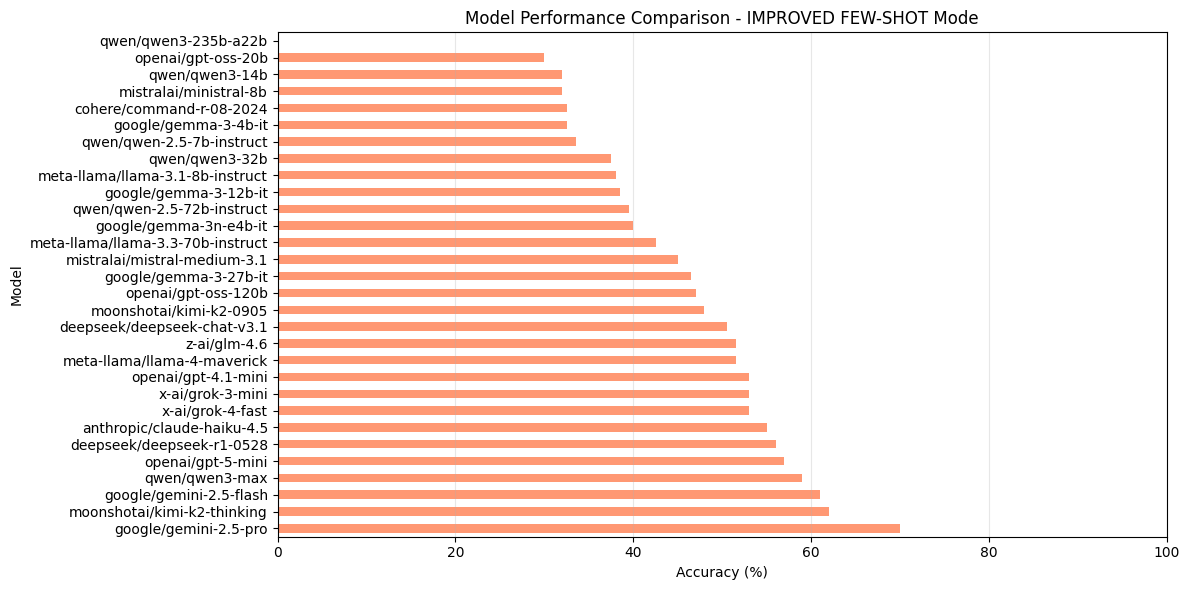


✅ Visualization complete


In [10]:
# Plot accuracy comparison
plt.figure(figsize=(12, 6))
model_stats['accuracy_pct'].plot(kind='barh', color='coral', alpha=0.8)
plt.xlabel('Accuracy (%)')
plt.ylabel('Model')
plt.title(f'Model Performance Comparison - IMPROVED {EXPERIMENT_MODE.upper()} Mode')
plt.xlim(0, 100)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ Visualization complete")